In [2]:
import pandas as pd
import numpy as np

# Load data

In [3]:
# fluxnet_results = pd.read_csv("results/fluxnet_runs_metrics.csv")
fluxnet_results = pd.read_csv("results/fluxnet_runs_metrics_15epochs.csv")
# fluxnet_dir_results = pd.read_csv("results/fluxnet-dir_runs_metrics_16epochs.csv")

# resmlp_results = pd.read_csv("results/resmlp_runs_metrics.csv")
resmlp_results = pd.read_csv("results/resmlp_runs_metrics_15epochs.csv")
# resmlp_dir_results = pd.read_csv("results/resmlp-dir_runs_metrics_16epochs.csv")

## FluxNet

In [4]:
print("FluxNet on Train:")
print(f"Mean train MAE: {fluxnet_results['train_mae'].mean():.3f}")
print(f"Std  train MAE: {fluxnet_results['train_mae'].std():.3f}")
print("")
print(f"Mean train RMSE: {fluxnet_results['train_rmse'].mean():.3f}")
print(f"Std  train RMSE: {fluxnet_results['train_rmse'].std():.3f}")

FluxNet on Train:
Mean train MAE: 0.048
Std  train MAE: 0.005

Mean train RMSE: 0.093
Std  train RMSE: 0.006


In [5]:
print("FluxNet on Test:")
print(f"Mean test  MAE: {fluxnet_results['test_mae'].mean():.3f}")
print(f"Std  test  MAE: {fluxnet_results['test_mae'].std():.3f}")
print("")
print(f"Mean test  RMSE: {fluxnet_results['test_rmse'].mean():.3f}")
print(f"Std  test  RMSE: {fluxnet_results['test_rmse'].std():.3f}")

FluxNet on Test:
Mean test  MAE: 0.058
Std  test  MAE: 0.004

Mean test  RMSE: 0.101
Std  test  RMSE: 0.005


# ResMLP

In [6]:
print("ResMLP on Train:")
print(f"Mean train  MAE: {resmlp_results['train_mae'].mean():.3f}")
print(f"Std  train  MAE: {resmlp_results['train_mae'].std():.3f}")
print("")
print(f"Mean train  RMSE: {resmlp_results['train_rmse'].mean():.3f}")
print(f"Std  train  RMSE: {resmlp_results['train_rmse'].std():.3f}")

ResMLP on Train:
Mean train  MAE: 0.050
Std  train  MAE: 0.010

Mean train  RMSE: 0.097
Std  train  RMSE: 0.014


In [7]:
print("ResMLP on Test:")
print(f"Mean test  MAE: {resmlp_results['test_mae'].mean():.3f}")
print(f"Std  test  MAE: {resmlp_results['test_mae'].std():.3f}")
print("")
print(f"Mean test  RMSE: {resmlp_results['test_rmse'].mean():.3f}")
print(f"Std  test  RMSE: {resmlp_results['test_rmse'].std():.3f}")

ResMLP on Test:
Mean test  MAE: 0.063
Std  test  MAE: 0.008

Mean test  RMSE: 0.114
Std  test  RMSE: 0.009


# Barchart

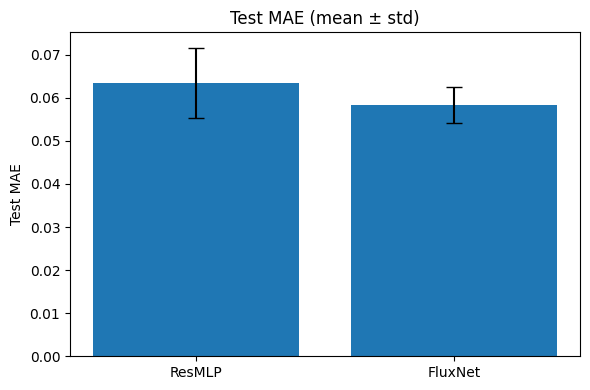

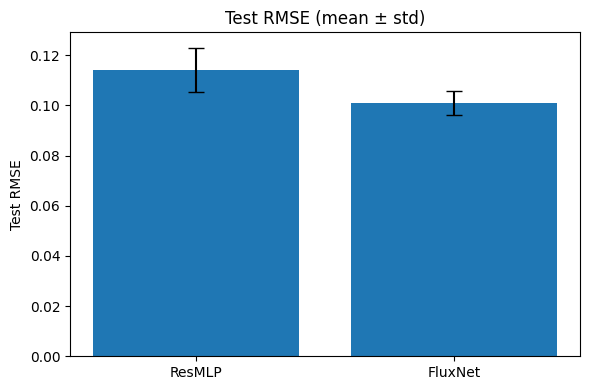

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---- compute means + stds ----
models = ["ResMLP", "FluxNet"]

mae_mean = [resmlp_results["test_mae"].mean(),  fluxnet_results["test_mae"].mean()]
mae_std  = [resmlp_results["test_mae"].std(),   fluxnet_results["test_mae"].std()]

rmse_mean = [resmlp_results["test_rmse"].mean(), fluxnet_results["test_rmse"].mean()]
rmse_std  = [resmlp_results["test_rmse"].std(),  fluxnet_results["test_rmse"].std()]

# ---- bar chart: MAE ----
x = np.arange(len(models))
plt.figure(figsize=(6, 4))
plt.bar(x, mae_mean, yerr=mae_std, capsize=6)
plt.xticks(x, models)
plt.ylabel("Test MAE")
plt.title("Test MAE (mean ± std)")
plt.tight_layout()
plt.show()

# ---- bar chart: RMSE ----
plt.figure(figsize=(6, 4))
plt.bar(x, rmse_mean, yerr=rmse_std, capsize=6)
plt.xticks(x, models)
plt.ylabel("Test RMSE")
plt.title("Test RMSE (mean ± std)")
plt.tight_layout()
plt.show()


In [ ]:
# Welch t-test
t, p = st.ttest_ind(flux, nn, equal_var=False)

# Mann–Whitney
u, p_u = st.mannwhitneyu(flux, nn, alternative="two-sided")

# Convergences

In [9]:
fluxnet_conv = pd.read_csv("trained_models/fluxnet_trained_15epochs_loss_convergence.csv")
resmlp_conv = pd.read_csv("trained_models/resmlp_trained_15epochs_loss_convergence.csv")

# add epoch column
fluxnet_conv["epoch"] = range(1, len(fluxnet_conv) + 1)
resmlp_conv["epoch"]  = range(1, len(resmlp_conv) + 1)

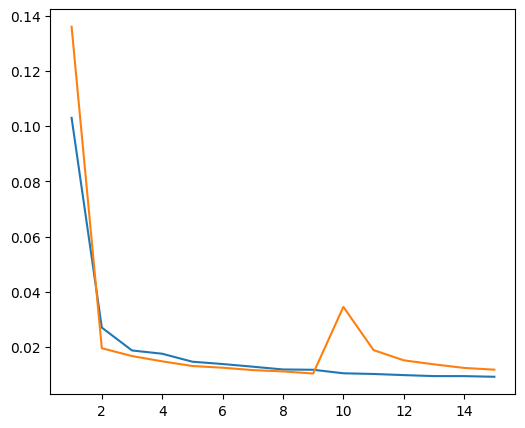

In [10]:
plt.figure(figsize = (6, 5))
plt.plot(fluxnet_conv["epoch"], fluxnet_conv["train_loss"], label = "FluxNet Train Loss")
plt.plot(resmlp_conv["epoch"], resmlp_conv["train_loss"], label = "ResMLP Train Loss")
plt.show()